# Hands on lap
___

### 1.Import Required Libraries

In [200]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### Explanation:

This code imports the libraries required for data analysis and visualization.
- Pandas (pd): Used for data manipulation and analysis.
- Matplotlib (plt): Used for creating graphs and plots.
- Seaborn (sns): Used for statistical data visualization.
- NumPy (np): Used for numerical computations.

___

### 2.Load the Dataset

In [201]:
df=pd.read_csv("homework.csv")
df.head()

,ID,Name,Class,Mark,Gender,Age,Hours_Studied
0,1,John,Fifth,75.0,Male,11,3
1,2,Jane,Fourth,85.0,Female,10,5
2,3,Mike,Third,95.0,Male,9,7
3,4,Lisa,Second,90.0,Female,8,6
4,5,Tom,Fifth,70.0,Male,11,2


#### Explanation:

This code loads the dataset from the CSV file and displays the first five rows.
- read_csv() reads the dataset.
- head() provides a quick preview of the data.

**Purpose**:
To verify that the dataset was loaded correctly.

___

### 3.Display Dataset Information

In [202]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             38 non-null     int64  
 1   Name           38 non-null     str    
 2   Class          38 non-null     str    
 3   Mark           33 non-null     float64
 4   Gender         38 non-null     str    
 5   Age            38 non-null     int64  
 6   Hours_Studied  38 non-null     int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 2.2 KB


#### Explanation:

This function provides a summary of the dataset including:
- Number of rows and columns
- Data types of each column
- Number of non-null values

**Purpose**:
To understand the structure of the dataset and identify missing values.

___

### 4.Check Dataset Dimensions

In [203]:
df.shape

(38, 7)

#### Explanation:

Returns the dimensions of the dataset.
**Output**:
(Number of Rows, Number of Columns)

**Purpose**:
To determine the size of the dataset.

___

### 5.Generate Descriptive Statistics

In [204]:
df.describe()

,ID,Mark,Age,Hours_Studied
count,38.000000,33.000000,38.000000,38.000000
mean,20.447368,79.090909,9.710526,4.552632
std,11.999318,11.334030,2.192221,2.226346
min,1.000000,45.000000,7.000000,1.000000
25%,10.250000,71.000000,8.250000,3.000000
50%,19.500000,82.000000,9.500000,5.000000
75%,30.750000,88.000000,11.000000,6.000000
max,40.000000,95.000000,20.000000,12.000000


#### Explanation:

Calculates summary statistics for numerical columns.
**Includes**:
- Mean
- Standard Deviation
- Minimum Value
- Maximum Value
- Quartiles

**Purpose**:
To gain a general understanding of the numerical data.

___

### 6.Check Missing Values

In [205]:
df.isnull().sum()

ID               0
Name             0
Class            0
Mark             5
Gender           0
Age              0
Hours_Studied    0
dtype: int64

#### Explanation:

Counts the number of missing values in each column.

**Purpose**:
To identify columns that require data cleaning.

___

### 7.Fill Missing Values

In [206]:
df["Mark"]=df["Mark"].fillna(df["Mark"].mean())
df.isnull().sum()

ID               0
Name             0
Class            0
Mark             0
Gender           0
Age              0
Hours_Studied    0
dtype: int64

#### Explanation:

Missing values in the Mark column are replaced with the column mean.
- fillna() fills missing values.
- mean() calculates the average mark.

**Purpose**:
To handle missing data while preserving the dataset.

___

### 8.Calculate the Mode

In [207]:
mode=df[["Age","Mark","Hours_Studied"]].mode()
mode

,Age,Mark,Hours_Studied
0,11,79.090909,6


#### Explanation:

Calculates the most frequently occurring value for each selected column.

**Purpose**:
To identify the most common values in the dataset.

___

### 9.Calculate Variance

In [208]:
var=df[["Age","Mark","Hours_Studied"]].var()
var

Age                4.805832
Mark             111.100737
Hours_Studied      4.956615
dtype: float64

#### Explanation:

Computes the variance of numerical variables.

**Purpose**:
To measure how spread out the data is around the mean.

**Interpretation**:
- Higher variance → Greater variability.
- Lower variance → Data points are closer to the mean.

___

### 10.Calculate Range

In [209]:
range=df[["Age","Mark","Hours_Studied"]].max()-df[["Age","Mark","Hours_Studied"]].min()
range

Age              13.0
Mark             50.0
Hours_Studied    11.0
dtype: float64

#### Explanation:

Calculates the range for each variable.
Range = Maximum Value − Minimum Value

**Purpose**:
To measure the overall spread of the data.

___

### 11.Distribution of Student Marks

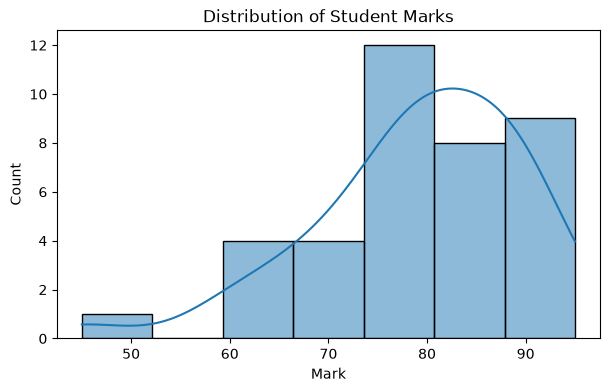

In [210]:
plt.figure(figsize=(7,4))
sns.histplot(data=df,x="Mark",kde=True)
plt.title("Distribution of Student Marks")
plt.show()

#### Explanation:

Creates a histogram showing the distribution of student marks.
- Histogram displays frequency distribution.
- KDE curve shows the overall data trend.

**Purpose**:
To understand how marks are distributed across students.

___

### 12.Distribution of Study Hours

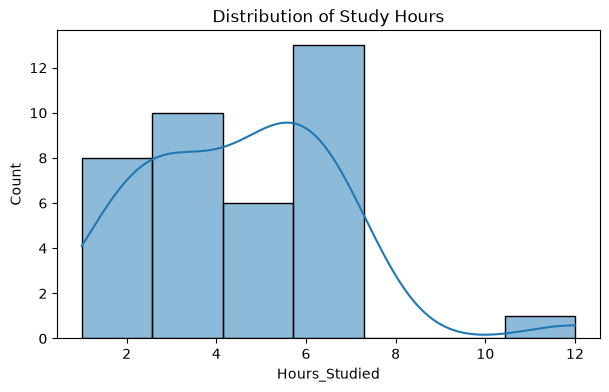

In [211]:
plt.figure(figsize=(7,4))
sns.histplot(data=df,x="Hours_Studied",kde=True)
plt.title("Distribution of Study Hours")
plt.show()

#### Explanation:

Visualizes the distribution of study hours.

**Purpose**:
To observe whether students tend to study similar numbers of hours or if there is significant variation.

___

### 13.Detect Age Outliers

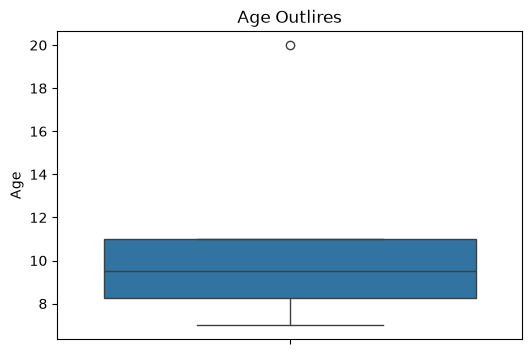

In [212]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df,y="Age")
plt.title("Age Outlires")
plt.show()

#### Explanation:

Creates a box plot for the Age column.

**Purpose**:
To identify unusual age values (outliers) that may affect analysis.

___

### 14.Detect Study Hours Outliers

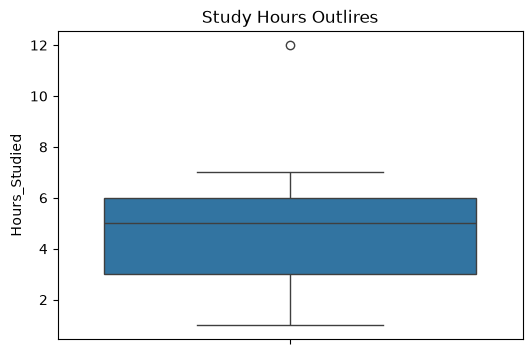

In [213]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df,y="Hours_Studied")
plt.title("Study Hours Outlires")
plt.show()

#### Explanation:

Displays potential outliers in study hours.

**Purpose**:
To find students whose study hours differ significantly from the rest.

___

### 15.Identify Outliers Using IQR Method

In [214]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

l = Q1 - 1.5 * IQR
u = Q3 + 1.5 * IQR
outliers = df[
        (df["Age"] < l) |
        (df["Age"] > u)
    ]
print(outliers)

    ID  Name   Class  Mark Gender  Age  Hours_Studied
37  40  Jack  Fourth  45.0   Male   20              7


#### Explanation:

This code uses the Interquartile Range (IQR) method to detect outliers.
**Steps**:
- Calculate Q1 and Q3.
- Compute IQR.
- Determine lower and upper limits.
- Identify values outside these limits.

**Purpose**:
To accurately detect extreme age values.

___

### 16.Remove Outliers

In [215]:


df = df[(df["Age"] >= l) & (df["Age"] <= u)]
df


,ID,Name,Class,Mark,Gender,Age,Hours_Studied
0,1,John,Fifth,75.000000,Male,11,3
1,2,Jane,Fourth,85.000000,Female,10,5
2,3,Mike,Third,95.000000,Male,9,7
3,4,Lisa,Second,90.000000,Female,8,6
4,5,Tom,Fifth,70.000000,Male,11,2
5,6,Sara,Third,80.000000,Female,9,4
6,7,Paul,Fourth,79.090909,Male,10,3
7,8,Anna,Second,88.000000,Female,8,6
8,9,Kate,First,65.000000,Female,7,2
9,10,Jim,Third,78.000000,Male,9,4


#### Explanation:

Removes rows containing age outliers.

**Purpose**:
To improve data quality and reduce the impact of extreme values.

___

### 17.Analyze Relationship Between Study Hours and Marks

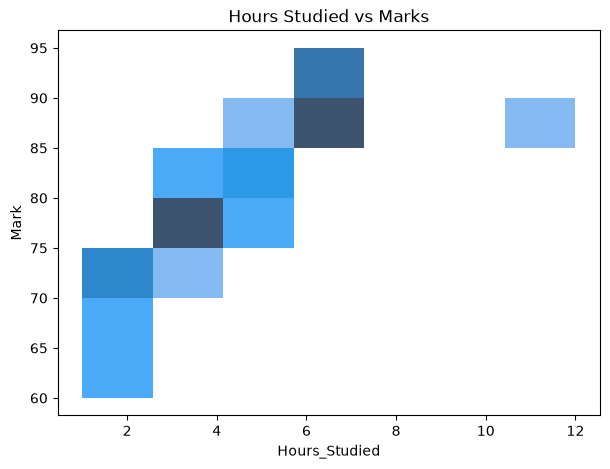

In [216]:
plt.figure(figsize=(7,5))
sns.histplot(data=df,x="Hours_Studied",y="Mark")
plt.title("Hours Studied vs Marks")
plt.show()

#### Explanation:

Visualizes the relationship between study hours and marks.

**Purpose**:
To determine whether studying more is associated with higher marks.

___

### 18.Marks Distribution by Class

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Class",y="Mark")
plt.title("Marks Distribution by class")
plt.show()

#### Explanation:

Compares mark distributions across different classes.

**Purpose**:
To identify differences in academic performance between classes.

___

### 19.Calculate Correlation Matrix

In [ ]:
corr=df.corr(numeric_only=True)
corr

,ID,Mark,Age,Hours_Studied
ID,1.000000,0.019394,0.053604,0.073201
Mark,0.019394,1.000000,0.136258,0.857762
Age,0.053604,0.136258,1.000000,-0.043232
Hours_Studied,0.073201,0.857762,-0.043232,1.000000


#### Explanation:

Calculates correlation coefficients among numerical variables.

**Purpose**:
To measure the strength and direction of relationships between variables.

___

### 20.Correlation Heatmap

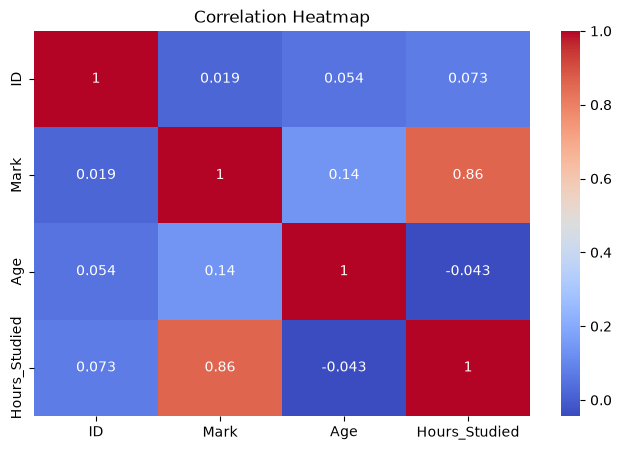

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### Explanation:

Displays correlations using color intensity.

**Purpose**:
To quickly identify strong positive or negative relationships among variables.

___

### 21.Pair Plot Analysis

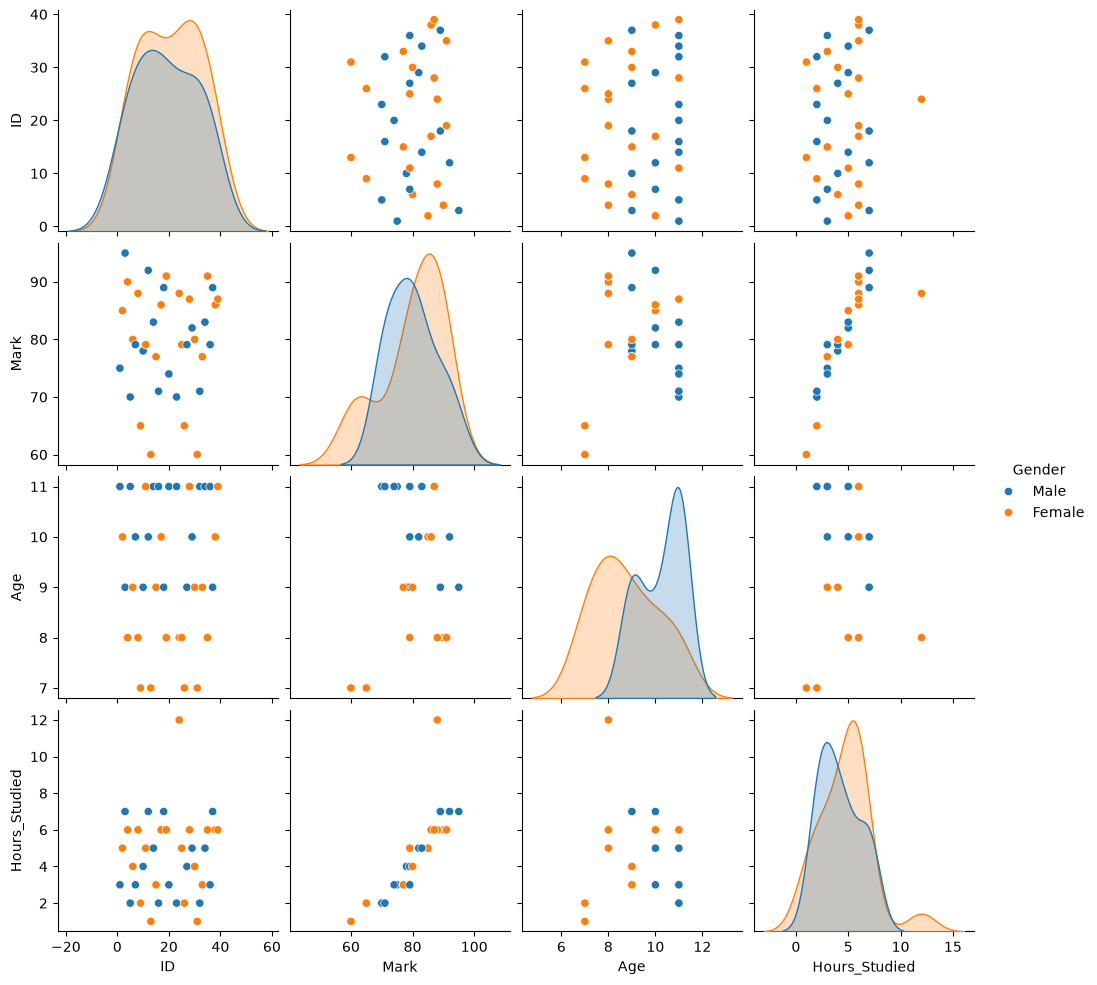

In [ ]:
sns.pairplot(df,hue="Gender")
plt.show()

#### Explanation:

Creates pairwise visualizations for all variables and colors them by gender.

**To explore**:
- Variable relationships
- Data distributions
- Gender-based patterns
- Clusters and trends within the dataset